In [1]:
!pip install pandas scikit-learn nltk

In [3]:
import pandas as pd
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [11]:
data = {
    'Ticket': [
        'Payment failed',
        'Refund not received',
        'Cannot login',
        'Password reset issue',
        'Website not loading',
        'Account suspended',
        'Order delayed',
        'Payment declined',
        'Need invoice copy',
        'Profile update issue',
        'Login error',
        'Refund taking too long'
    ],
    'Category': [
        'Billing',
        'Billing',
        'Technical',
        'Technical',
        'Technical',
        'Account',
        'Billing',
        'Billing',
        'Billing',
        'Account',
        'Technical',
        'Billing'
    ]
}

df = pd.DataFrame(data)

df.head()

,Ticket,Category
0,Payment failed,Billing
1,Refund not received,Billing
2,Cannot login,Technical
3,Password reset issue,Technical
4,Website not loading,Technical


In [12]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['Ticket'])

y = df['Category']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=1
)

In [14]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [15]:
predictions = model.predict(X_test)

print(predictions)

['Billing' 'Billing' 'Billing']


In [16]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.0


In [17]:
new_ticket = ["My payment is not processing"]

new_ticket_vector = vectorizer.transform(new_ticket)

prediction = model.predict(new_ticket_vector)

print("Predicted Category:", prediction[0])

Predicted Category: Billing


In [18]:
def priority(ticket):

    ticket = ticket.lower()

    if "payment" in ticket or "login" in ticket:
        return "High"

    elif "order" in ticket:
        return "Medium"

    else:
        return "Low"

In [19]:
print(priority("Unable to login"))

High


In [20]:
ticket = "Payment failed"

category = model.predict(
    vectorizer.transform([ticket])
)[0]

print("Ticket:", ticket)
print("Category:", category)
print("Priority:", priority(ticket))

Ticket: Payment failed
Category: Billing
Priority: High


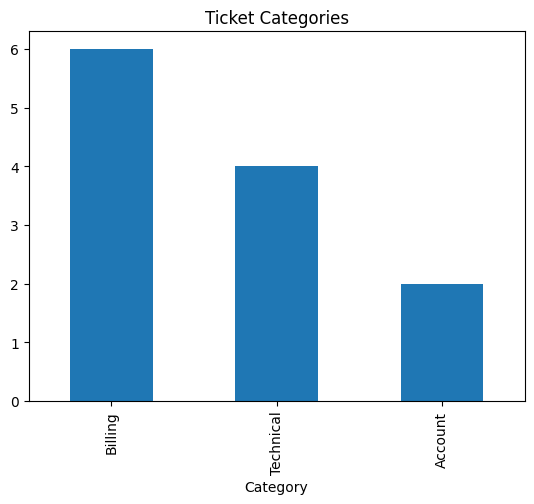

In [21]:
import matplotlib.pyplot as plt

df['Category'].value_counts().plot(kind='bar')

plt.title("Ticket Categories")

plt.show()

In [22]:
import pandas as pd

df = pd.read_csv('/content/customer_support_tickets.csv')

print(df.head())
print(df.columns)

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

X = df['Ticket Description']
y = df['Ticket Category']

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X.astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = MultinomialNB()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

KeyError: 'Ticket Category'

In [24]:
print(df.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


In [25]:
X = df['Ticket Description']
y = df['Ticket Type']

In [28]:
X = df['Ticket Description']
y = df['Ticket Type']

In [27]:
print(df.columns.tolist())

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [29]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Load CSV
df = pd.read_csv('/content/customer_support_tickets.csv')

# Features and target
X = df['Ticket Description'].astype(str)
y = df['Ticket Type']

# Convert text to numbers
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = MultinomialNB()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.19657615112160567


In [30]:
new_ticket = ["My payment failed and I need a refund"]

new_vector = vectorizer.transform(new_ticket)

prediction = model.predict(new_vector)

print("Predicted Ticket Type:", prediction[0])

Predicted Ticket Type: Product inquiry


In [31]:
y_priority = df['Ticket Priority']

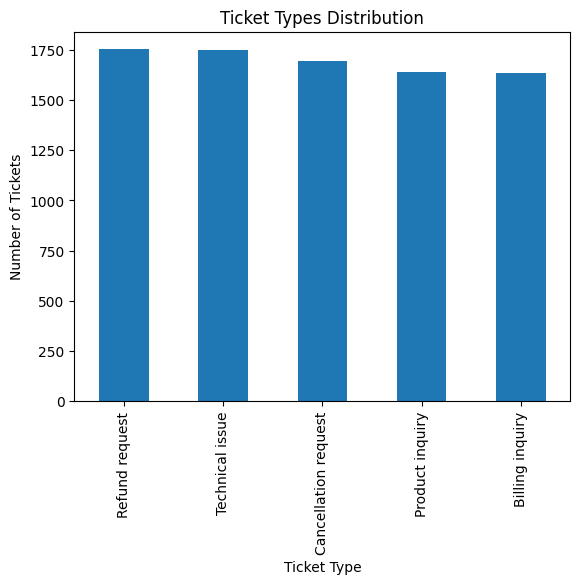

In [32]:
import matplotlib.pyplot as plt

df['Ticket Type'].value_counts().plot(kind='bar')

plt.title('Ticket Types Distribution')
plt.xlabel('Ticket Type')
plt.ylabel('Number of Tickets')

plt.show()

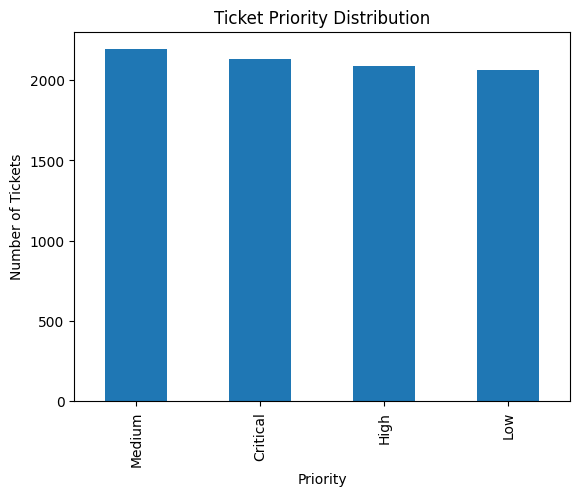

In [33]:
import matplotlib.pyplot as plt

df['Ticket Priority'].value_counts().plot(kind='bar')

plt.title('Ticket Priority Distribution')
plt.xlabel('Priority')
plt.ylabel('Number of Tickets')

plt.show()